# Modelado predictivo de NO₂

Este notebook desarrolla y evalúa un modelo para la predicción diaria de la concentración de NO₂ en las estaciones de calidad del aire de Madrid.

El objetivo es realizar una predicción a **un día vista**, utilizando como variables explicativas:

- concentraciones de NO₂ observadas en días anteriores;
- condiciones meteorológicas correspondientes al día objetivo;
- información temporal y de calendario;
- estación de calidad del aire.

La metodología se divide en tres periodos temporales independientes:

- **2020-2022:** entrenamiento.
- **2023:** validación, optimización de hiperparámetros y selección de variables.
- **2024:** test final.

El conjunto de test se mantiene fuera del proceso de selección del modelo y se utiliza únicamente para estimar su capacidad de generalización temporal.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================================================
# CARGA DEL DATASET DE MODELADO
# ============================================================

ROOT = Path.cwd()

while not (ROOT / "data").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "modeling" / "dataset_no2.parquet"

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado correctamente")
print("Shape:", df.shape)

display(df.head())

Dataset cargado correctamente
Shape: (40040, 24)


,fecha,estacion,contaminante_t,es_laborable_madrid_ciudad,direccion_racha_max,humedad_max,humedad_media,humedad_min,insolacion,precipitacion,...,temp_min,viento_racha,viento_velocidad,mes,mes_sin,mes_cos,no2_lag_1,no2_lag_2,no2_lag_3,no2_lag_7
0,2020-01-08,8,99.791667,True,90.0,72.0,47.0,27.0,8.8,0.0,...,1.8,3.3,0.3,1,0.5,0.866025,85.130435,60.083333,51.291667,65.666667
1,2020-01-09,8,77.958333,True,300.0,75.0,59.0,49.0,8.6,0.0,...,4.0,9.4,1.1,1,0.5,0.866025,99.791667,85.130435,60.083333,68.083333
2,2020-01-10,8,54.500000,True,40.0,73.0,50.0,37.0,8.9,0.0,...,4.2,9.7,3.3,1,0.5,0.866025,77.958333,99.791667,85.130435,73.458333
3,2020-01-11,8,56.625000,False,50.0,69.0,52.0,38.0,9.2,0.0,...,2.0,6.1,1.4,1,0.5,0.866025,54.500000,77.958333,99.791667,42.347826
4,2020-01-12,8,70.375000,False,170.0,76.0,69.0,56.0,9.1,0.0,...,-0.7,3.1,1.1,1,0.5,0.866025,56.625000,54.500000,77.958333,51.291667


In [2]:
print(df.columns.tolist())

['fecha', 'estacion', 'contaminante_t', 'es_laborable_madrid_ciudad', 'direccion_racha_max', 'humedad_max', 'humedad_media', 'humedad_min', 'insolacion', 'precipitacion', 'presion_max', 'presion_min', 'temp_max', 'temp_media', 'temp_min', 'viento_racha', 'viento_velocidad', 'mes', 'mes_sin', 'mes_cos', 'no2_lag_1', 'no2_lag_2', 'no2_lag_3', 'no2_lag_7']


In [3]:
# ============================================================
# FEATURES Y TARGET
# ============================================================

TARGET = "contaminante_t"

FEATURES = [
    # Meteorología
    "temp_media",
    "temp_min",
    "temp_max",
    "humedad_media",
    "humedad_min",
    "humedad_max",
    "insolacion",
    "precipitacion",
    "direccion_racha_max",
    "viento_velocidad",
    "viento_racha",
    "presion_max",
    "presion_min",

    # Calendario
    "es_laborable_madrid_ciudad",
    "mes_sin",
    "mes_cos",

    # Estación
    "estacion",

    # Lags NO2
    "no2_lag_1",
    "no2_lag_2",
    "no2_lag_3",
    "no2_lag_7",
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("Nulos en X:", X.isna().sum().sum())
print("Nulos en y:", y.isna().sum())

Shape X: (40040, 21)
Shape y: (40040,)
Nulos en X: 0
Nulos en y: 0


In [4]:
assert X.isna().sum().sum() == 0
assert y.isna().sum() == 0

## División temporal del dataset

Al tratarse de un problema de predicción temporal, el dataset se divide respetando el orden cronológico de las observaciones, evitando realizar una partición aleatoria que pudiera introducir información futura durante el entrenamiento.

Se establecen tres conjuntos independientes:

- **Entrenamiento (2020-2022):** utilizado para entrenar los modelos.
- **Validación (2023):** utilizado para comparar configuraciones, optimizar hiperparámetros y tomar decisiones sobre la selección de variables.
- **Test (2024):** reservado para la evaluación final del modelo seleccionado.

Esta división permite simular un escenario más cercano al uso real del modelo, en el que se utilizan observaciones históricas para realizar predicciones sobre periodos futuros.

Además, mantener 2024 como conjunto de test independiente permite obtener una estimación de la capacidad de generalización temporal del modelo sobre datos no utilizados durante su desarrollo.

In [5]:
# ============================================================
# SPLIT TEMPORAL: TRAIN / VALIDATION / TEST
# ============================================================

train_mask = df["fecha"] < "2023-01-01"

val_mask = (
    (df["fecha"] >= "2023-01-01")
    & (df["fecha"] < "2024-01-01")
)

test_mask = df["fecha"] >= "2024-01-01"


X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[val_mask].copy()
y_val = y.loc[val_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()


print("TRAIN")
print(
    df.loc[train_mask, "fecha"].min(),
    "→",
    df.loc[train_mask, "fecha"].max()
)
print("Observaciones:", len(X_train))

print("\nVALIDATION")
print(
    df.loc[val_mask, "fecha"].min(),
    "→",
    df.loc[val_mask, "fecha"].max()
)
print("Observaciones:", len(X_val))

print("\nTEST")
print(
    df.loc[test_mask, "fecha"].min(),
    "→",
    df.loc[test_mask, "fecha"].max()
)
print("Observaciones:", len(X_test))

print(
    "\nTotal:",
    len(X_train) + len(X_val) + len(X_test)
)

TRAIN
2020-01-08 00:00:00 → 2022-12-31 00:00:00
Observaciones: 23958

VALIDATION
2023-01-01 00:00:00 → 2023-12-31 00:00:00
Observaciones: 8030

TEST
2024-01-01 00:00:00 → 2024-12-31 00:00:00
Observaciones: 8052

Total: 40040


In [6]:
# ============================================================
# COMPROBACIÓN DEL SPLIT
# ============================================================

assert len(X_train) + len(X_val) + len(X_test) == len(df)

assert df.loc[train_mask, "fecha"].max() < df.loc[val_mask, "fecha"].min()
assert df.loc[val_mask, "fecha"].max() < df.loc[test_mask, "fecha"].min()

print("Split temporal correcto.")

Split temporal correcto.


## Modelo baseline

Como referencia se utiliza un modelo de **persistencia temporal**, que supone que la concentración de NO₂ del día siguiente será igual a la observada el día anterior.

Por tanto:

$$
\widehat{NO}_{2,t} = NO_{2,t-1}
$$

Este baseline permite determinar si el modelo desarrollado aporta capacidad predictiva adicional respecto a una estrategia temporal sencilla.

Durante la fase de desarrollo, la comparación con el baseline se realiza sobre el conjunto de validación de 2023.

In [7]:
# ============================================================
# BASELINE: PERSISTENCIA (NO2 DEL DÍA ANTERIOR)
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Predicción baseline
y_pred_baseline = X_test["no2_lag_1"]

# Métricas
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("BASELINE - Persistencia (lag 1)")
print("--------------------------------")
print(f"MAE:  {mae_baseline:.3f}")
print(f"RMSE: {rmse_baseline:.3f}")
print(f"R²:   {r2_baseline:.3f}")

BASELINE - Persistencia (lag 1)
--------------------------------
MAE:  6.796
RMSE: 9.100
R²:   0.563


In [8]:
# ============================================================
# TABLA DE RESULTADOS
# ============================================================

resultados = pd.DataFrame([
    {
        "modelo": "Baseline persistencia",
        "MAE": mae_baseline,
        "RMSE": rmse_baseline,
        "R2": r2_baseline
    }
])

display(resultados)

,modelo,MAE,RMSE,R2
0,Baseline persistencia,6.796186,9.099877,0.562799


In [9]:
# ============================================================
# XGBOOST - MODELO INICIAL
# ============================================================

from xgboost import XGBRegressor

modelo_xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

modelo_xgb.fit(
    X_train,
    y_train
)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


In [10]:
# ============================================================
# EVALUACIÓN EN VALIDATION
# ============================================================

y_pred_val = modelo_xgb.predict(X_val)

mae_val = mean_absolute_error(y_val, y_pred_val)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_val = r2_score(y_val, y_pred_val)

print("XGBOOST INICIAL - VALIDATION 2023")
print("----------------------------------")
print(f"MAE:  {mae_val:.3f}")
print(f"RMSE: {rmse_val:.3f}")
print(f"R²:   {r2_val:.3f}")

XGBOOST INICIAL - VALIDATION 2023
----------------------------------
MAE:  5.374
RMSE: 6.988
R²:   0.798


In [11]:
# ============================================================
# BASELINE - VALIDATION 2023
# ============================================================

y_pred_baseline_val = X_val["no2_lag_1"]

mae_baseline_val = mean_absolute_error(
    y_val,
    y_pred_baseline_val
)

rmse_baseline_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_baseline_val
    )
)

r2_baseline_val = r2_score(
    y_val,
    y_pred_baseline_val
)

print("BASELINE - VALIDATION 2023")
print("---------------------------")
print(f"MAE:  {mae_baseline_val:.3f}")
print(f"RMSE: {rmse_baseline_val:.3f}")
print(f"R²:   {r2_baseline_val:.3f}")


BASELINE - VALIDATION 2023
---------------------------
MAE:  7.781
RMSE: 10.710
R²:   0.526


,feature,importancia
17,no2_lag_1,0.439285
9,viento_velocidad,0.127458
13,es_laborable_madrid_ciudad,0.095437
10,viento_racha,0.061382
15,mes_cos,0.036147
20,no2_lag_7,0.033041
1,temp_min,0.031309
16,estacion,0.018065
4,humedad_min,0.016905
12,presion_min,0.014650


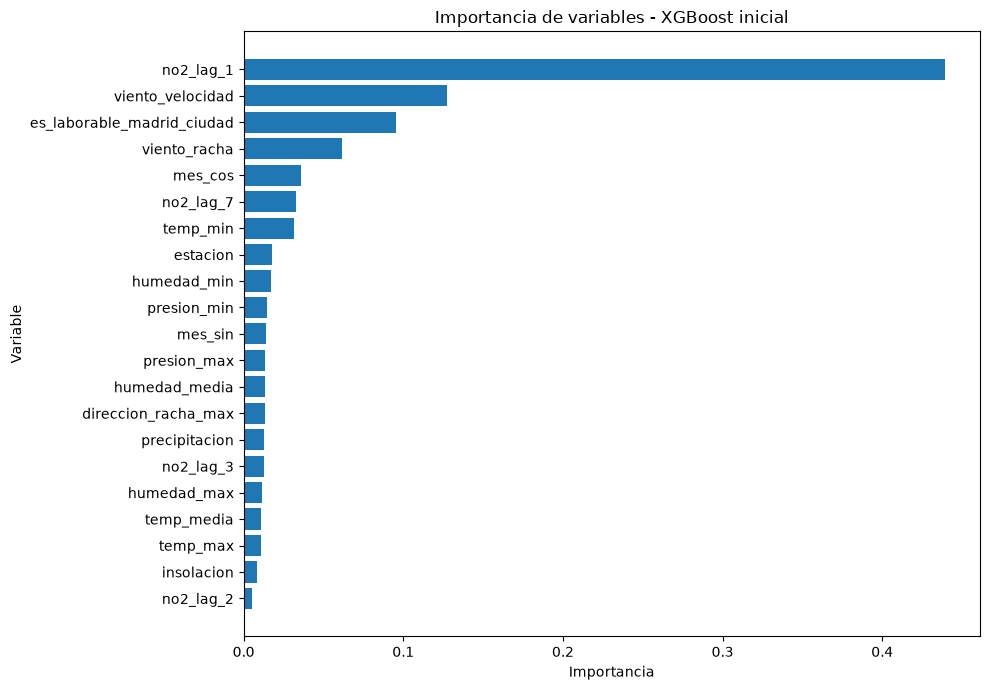

In [12]:
# ============================================================
# IMPORTANCIA DE VARIABLES - XGBOOST INICIAL
# ============================================================

import matplotlib.pyplot as plt

importancias = pd.DataFrame({
    "feature": FEATURES,
    "importancia": modelo_xgb.feature_importances_
}).sort_values(
    "importancia",
    ascending=False
)

display(importancias)

plt.figure(figsize=(10, 7))

plt.barh(
    importancias["feature"][::-1],
    importancias["importancia"][::-1]
)

plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.title("Importancia de variables - XGBoost inicial")

plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# ERROR DE VALIDACIÓN POR ESTACIÓN
# ============================================================

evaluacion_val = df.loc[
    val_mask,
    ["fecha", "estacion", TARGET]
].copy()

evaluacion_val["prediccion"] = y_pred_val

evaluacion_val["error_absoluto"] = (
    evaluacion_val[TARGET]
    - evaluacion_val["prediccion"]
).abs()

error_estacion = (
    evaluacion_val
    .groupby("estacion")
    .agg(
        n=("error_absoluto", "size"),
        MAE=("error_absoluto", "mean")
    )
    .sort_values("MAE")
)

display(error_estacion)

,n,MAE
estacion,,
58,365,2.938709
24,365,4.307134
49,365,4.607677
18,365,4.883148
59,365,4.885885
60,365,4.904565
57,365,5.122095
50,365,5.175022
48,365,5.275147


## Optimización de hiperparámetros

Una vez establecido el modelo inicial, se realiza una búsqueda de hiperparámetros utilizando exclusivamente el conjunto de validación de 2023.

Se exploran diferentes combinaciones de profundidad máxima de los árboles, tasa de aprendizaje, número de estimadores, proporción de observaciones utilizada por árbol y proporción de variables utilizadas.

La configuración final se selecciona priorizando el menor MAE en validación. El conjunto de test de 2024 no interviene en este proceso.

In [14]:
# ============================================================
# TUNING DE XGBOOST SOBRE VALIDATION
# ============================================================

from itertools import product

resultados_tuning = []

param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "n_estimators": [300, 500, 800],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

combinaciones = list(product(
    param_grid["max_depth"],
    param_grid["learning_rate"],
    param_grid["n_estimators"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
))

print("Número de combinaciones:", len(combinaciones))

Número de combinaciones: 108


In [15]:
# ============================================================
# BÚSQUEDA DE HIPERPARÁMETROS
# ============================================================

for i, (
    max_depth,
    learning_rate,
    n_estimators,
    subsample,
    colsample_bytree
) in enumerate(combinaciones, start=1):

    modelo = XGBRegressor(
        objective="reg:squarederror",
        max_depth=max_depth,
        learning_rate=learning_rate,
        n_estimators=n_estimators,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    pred_val = modelo.predict(X_val)

    mae = mean_absolute_error(y_val, pred_val)
    rmse = np.sqrt(mean_squared_error(y_val, pred_val))
    r2 = r2_score(y_val, pred_val)

    resultados_tuning.append({
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "n_estimators": n_estimators,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    if i % 10 == 0:
        print(f"Completadas {i}/{len(combinaciones)}")

Completadas 10/108
Completadas 20/108
Completadas 30/108
Completadas 40/108
Completadas 50/108
Completadas 60/108
Completadas 70/108
Completadas 80/108
Completadas 90/108
Completadas 100/108


In [16]:
# ============================================================
# RESULTADOS DEL TUNING
# ============================================================

resultados_tuning = (
    pd.DataFrame(resultados_tuning)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(resultados_tuning.head(15))

,max_depth,learning_rate,n_estimators,subsample,colsample_bytree,MAE,RMSE,R2
0,7,0.03,800,0.8,0.8,5.308114,6.920000,0.802236
1,7,0.03,500,0.8,0.8,5.323954,6.924633,0.801972
2,7,0.05,500,0.8,0.8,5.327807,6.956347,0.800154
3,7,0.05,800,0.8,0.8,5.333060,6.969154,0.799417
4,7,0.05,300,0.8,0.8,5.334191,6.943181,0.800909
5,7,0.03,300,0.8,0.8,5.337370,6.925385,0.801929
6,5,0.03,800,0.8,1.0,5.341705,6.952495,0.800375
7,7,0.03,800,1.0,0.8,5.346149,6.943664,0.800882
8,5,0.03,500,0.8,1.0,5.348032,6.944300,0.800845
9,7,0.10,500,1.0,0.8,5.353323,6.951198,0.800449


In [17]:
# ============================================================
# MEJOR CONFIGURACIÓN XGBOOST
# ============================================================

mejores_params = {
    "max_depth": 7,
    "learning_rate": 0.03,
    "n_estimators": 800,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

modelo_xgb_opt = XGBRegressor(
    objective="reg:squarederror",
    **mejores_params,
    random_state=42,
    n_jobs=-1
)

modelo_xgb_opt.fit(X_train, y_train)

y_pred_val_opt = modelo_xgb_opt.predict(X_val)

print("XGBOOST OPTIMIZADO - VALIDATION 2023")
print("-------------------------------------")
print(f"MAE:  {mean_absolute_error(y_val, y_pred_val_opt):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_pred_val_opt)):.3f}")
print(f"R²:   {r2_score(y_val, y_pred_val_opt):.3f}")

XGBOOST OPTIMIZADO - VALIDATION 2023
-------------------------------------
MAE:  5.308
RMSE: 6.920
R²:   0.802


## Selección de variables

Tras optimizar los hiperparámetros se estudia si es posible simplificar el modelo eliminando variables con baja contribución o información potencialmente redundante.

Para ello se comparan diferentes conjuntos de variables manteniendo fija la configuración optimizada de XGBoost. Todas las comparaciones se realizan sobre el conjunto de validación de 2023.

El objetivo no es únicamente minimizar el error, sino obtener un modelo que mantenga una buena capacidad predictiva evitando complejidad innecesaria.

In [18]:
# ============================================================
# EXPERIMENTOS DE SELECCIÓN DE FEATURES
# ============================================================

experimentos = {

    "Completo": FEATURES,

    "Sin extremos meteo": [
        f for f in FEATURES
        if f not in [
            "temp_min",
            "temp_max",
            "humedad_min",
            "humedad_max",
            "presion_max"
        ]
    ],

    "Sin lag_2": [
        f for f in FEATURES
        if f != "no2_lag_2"
    ],

    "Solo lag_1 y lag_7": [
        f for f in FEATURES
        if f not in [
            "no2_lag_2",
            "no2_lag_3"
        ]
    ],

    "Reducido": [
        f for f in FEATURES
        if f not in [
            "no2_lag_2",
            "temp_max",
            "temp_media",
            "humedad_max",
            "insolacion"
        ]
    ]
}

In [19]:
# ============================================================
# COMPARACIÓN DE CONJUNTOS DE FEATURES
# ============================================================

resultados_features = []

for nombre, features_exp in experimentos.items():

    modelo = XGBRegressor(
        objective="reg:squarederror",
        **mejores_params,
        random_state=42,
        n_jobs=-1
    )

    modelo.fit(
        X_train[features_exp],
        y_train
    )

    pred = modelo.predict(
        X_val[features_exp]
    )

    resultados_features.append({
        "modelo": nombre,
        "n_features": len(features_exp),
        "MAE": mean_absolute_error(y_val, pred),
        "RMSE": np.sqrt(mean_squared_error(y_val, pred)),
        "R2": r2_score(y_val, pred)
    })

resultados_features = (
    pd.DataFrame(resultados_features)
    .sort_values("MAE")
    .reset_index(drop=True)
)

display(resultados_features)

,modelo,n_features,MAE,RMSE,R2
0,Completo,21,5.308114,6.920000,0.802236
1,Sin lag_2,20,5.310586,6.916136,0.802457
2,Solo lag_1 y lag_7,19,5.338302,6.918823,0.802304
3,Reducido,16,5.443281,7.027506,0.796044
4,Sin extremos meteo,16,5.485619,7.125112,0.790339


In [20]:
FEATURES_FINAL = FEATURES.copy()

PARAMS_FINAL = {
    "max_depth": 7,
    "learning_rate": 0.03,
    "n_estimators": 800,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

In [21]:
# ============================================================
# REENTRENAMIENTO DEL MODELO FINAL
# TRAIN: 2020-2023
# ============================================================

train_final_mask = df["fecha"] < "2024-01-01"

X_train_final = df.loc[
    train_final_mask,
    FEATURES_FINAL
].copy()

y_train_final = df.loc[
    train_final_mask,
    TARGET
].copy()

X_test_final = df.loc[
    test_mask,
    FEATURES_FINAL
].copy()

y_test_final = df.loc[
    test_mask,
    TARGET
].copy()

print("Train final:", X_train_final.shape)
print("Test final:", X_test_final.shape)

print(
    "Periodo train final:",
    df.loc[train_final_mask, "fecha"].min(),
    "→",
    df.loc[train_final_mask, "fecha"].max()
)

print(
    "Periodo test:",
    df.loc[test_mask, "fecha"].min(),
    "→",
    df.loc[test_mask, "fecha"].max()
)

Train final: (31988, 21)
Test final: (8052, 21)
Periodo train final: 2020-01-08 00:00:00 → 2023-12-31 00:00:00
Periodo test: 2024-01-01 00:00:00 → 2024-12-31 00:00:00


In [22]:
# ============================================================
# MODELO XGBOOST FINAL
# ============================================================

modelo_final = XGBRegressor(
    objective="reg:squarederror",
    **PARAMS_FINAL,
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(
    X_train_final,
    y_train_final
)

print("Modelo final entrenado correctamente.")

Modelo final entrenado correctamente.


## Entrenamiento y evaluación final

Una vez seleccionados los hiperparámetros y el conjunto definitivo de variables utilizando exclusivamente los datos de entrenamiento y validación, se cierra la fase de desarrollo del modelo.

El modelo final se reentrena utilizando conjuntamente los datos de **2020-2023**, aprovechando toda la información disponible anterior al periodo de test.

Posteriormente se realiza una única evaluación sobre **2024**, periodo que no ha intervenido en la selección de hiperparámetros ni de variables.

A partir de este punto, los resultados obtenidos sobre 2024 se utilizan exclusivamente para evaluar e interpretar el modelo final, no para realizar nuevas modificaciones sobre su configuración.

In [23]:
# ============================================================
# EVALUACIÓN FINAL - TEST 2024
# ============================================================

y_pred_test = modelo_final.predict(X_test_final)

mae_test = mean_absolute_error(
    y_test_final,
    y_pred_test
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_final,
        y_pred_test
    )
)

r2_test = r2_score(
    y_test_final,
    y_pred_test
)

print("XGBOOST FINAL - TEST 2024")
print("--------------------------")
print(f"MAE:  {mae_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"R²:   {r2_test:.3f}")

XGBOOST FINAL - TEST 2024
--------------------------
MAE:  4.619
RMSE: 5.972
R²:   0.812


In [24]:
# ============================================================
# COMPARACIÓN FINAL CON BASELINE
# ============================================================

comparacion_final = pd.DataFrame([
    {
        "modelo": "Baseline persistencia",
        "MAE": mae_baseline,
        "RMSE": rmse_baseline,
        "R2": r2_baseline
    },
    {
        "modelo": "XGBoost final",
        "MAE": mae_test,
        "RMSE": rmse_test,
        "R2": r2_test
    }
])

display(comparacion_final)

mejora_mae = (
    (mae_baseline - mae_test)
    / mae_baseline
    * 100
)

mejora_rmse = (
    (rmse_baseline - rmse_test)
    / rmse_baseline
    * 100
)

print(f"Reducción del MAE frente al baseline: {mejora_mae:.2f}%")
print(f"Reducción del RMSE frente al baseline: {mejora_rmse:.2f}%")

,modelo,MAE,RMSE,R2
0,Baseline persistencia,6.796186,9.099877,0.562799
1,XGBoost final,4.618749,5.971903,0.811706


Reducción del MAE frente al baseline: 32.04%
Reducción del RMSE frente al baseline: 34.37%


In [25]:
# ============================================================
# CONTEXTO DEL ERROR DEL MODELO
# ============================================================

print("Distribución NO2 - Test 2024")
print("-----------------------------")

print(f"Media:   {y_test_final.mean():.2f}")
print(f"Mediana: {y_test_final.median():.2f}")
print(f"Mínimo:  {y_test_final.min():.2f}")
print(f"Máximo:  {y_test_final.max():.2f}")

print("\nPercentiles:")
display(
    y_test_final.quantile(
        [0.05, 0.25, 0.50, 0.75, 0.95]
    )
)

print(
    f"\nMAE / concentración media: "
    f"{mae_test / y_test_final.mean() * 100:.2f}%"
)

Distribución NO2 - Test 2024
-----------------------------
Media:   22.97
Mediana: 19.50
Mínimo:  1.29
Máximo:  88.42

Percentiles:


0.05     6.311957
0.25    12.208333
0.50    19.500000
0.75    31.541667
0.95    49.935417
Name: contaminante_t, dtype: float64


MAE / concentración media: 20.11%


In [26]:
# ============================================================
# EXPERIMENTO: SIN VARIABLES METEO IMPUTADAS
# ============================================================

variables_imputadas = [
    "insolacion",
    "humedad_min",
    "humedad_max"
]

FEATURES_SIN_IMPUTADAS = [
    f for f in FEATURES
    if f not in variables_imputadas
]

print("Features modelo completo:", len(FEATURES))
print("Features sin imputadas:", len(FEATURES_SIN_IMPUTADAS))
print("\nVariables eliminadas:")
print(variables_imputadas)

Features modelo completo: 21
Features sin imputadas: 18

Variables eliminadas:
['insolacion', 'humedad_min', 'humedad_max']


In [27]:
# ============================================================
# XGBOOST SIN VARIABLES METEO IMPUTADAS - VALIDATION 2023
# ============================================================

modelo_sin_imputadas = XGBRegressor(
    objective="reg:squarederror",
    **mejores_params,
    random_state=42,
    n_jobs=-1
)

modelo_sin_imputadas.fit(
    X_train[FEATURES_SIN_IMPUTADAS],
    y_train
)

y_pred_sin_imputadas_val = modelo_sin_imputadas.predict(
    X_val[FEATURES_SIN_IMPUTADAS]
)

mae_sin_imputadas_val = mean_absolute_error(
    y_val,
    y_pred_sin_imputadas_val
)

rmse_sin_imputadas_val = np.sqrt(
    mean_squared_error(
        y_val,
        y_pred_sin_imputadas_val
    )
)

r2_sin_imputadas_val = r2_score(
    y_val,
    y_pred_sin_imputadas_val
)

print("XGBOOST SIN VARIABLES IMPUTADAS - VALIDATION 2023")
print("--------------------------------------------------")
print(f"MAE:  {mae_sin_imputadas_val:.3f}")
print(f"RMSE: {rmse_sin_imputadas_val:.3f}")
print(f"R²:   {r2_sin_imputadas_val:.3f}")

XGBOOST SIN VARIABLES IMPUTADAS - VALIDATION 2023
--------------------------------------------------
MAE:  5.329
RMSE: 6.963
R²:   0.800


In [28]:
comparacion_imputadas = pd.DataFrame([
    {
        "modelo": "Completo",
        "n_features": 21,
        "MAE": 5.308114,
        "RMSE": 6.920000,
        "R2": 0.802236
    },
    {
        "modelo": "Sin insolacion + humedad min/max",
        "n_features": len(FEATURES_SIN_IMPUTADAS),
        "MAE": mae_sin_imputadas_val,
        "RMSE": rmse_sin_imputadas_val,
        "R2": r2_sin_imputadas_val
    }
])

display(comparacion_imputadas)

,modelo,n_features,MAE,RMSE,R2
0,Completo,21,5.308114,6.920000,0.802236
1,Sin insolacion + humedad min/max,18,5.329331,6.962732,0.799787


In [29]:
# ============================================================
# CONFIGURACIÓN FINAL DEL MODELO
# ============================================================

FEATURES_FINAL = FEATURES_SIN_IMPUTADAS.copy()

PARAMS_FINAL = {
    "max_depth": 7,
    "learning_rate": 0.03,
    "n_estimators": 800,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
}

print("Número de features finales:", len(FEATURES_FINAL))
print(FEATURES_FINAL)

Número de features finales: 18
['temp_media', 'temp_min', 'temp_max', 'humedad_media', 'precipitacion', 'direccion_racha_max', 'viento_velocidad', 'viento_racha', 'presion_max', 'presion_min', 'es_laborable_madrid_ciudad', 'mes_sin', 'mes_cos', 'estacion', 'no2_lag_1', 'no2_lag_2', 'no2_lag_3', 'no2_lag_7']


In [30]:
# ============================================================
# TRAIN FINAL / TEST
# ============================================================

train_final_mask = df["fecha"] < "2024-01-01"
test_final_mask = df["fecha"] >= "2024-01-01"

X_train_final = df.loc[
    train_final_mask,
    FEATURES_FINAL
].copy()

y_train_final = df.loc[
    train_final_mask,
    TARGET
].copy()

X_test_final = df.loc[
    test_final_mask,
    FEATURES_FINAL
].copy()

y_test_final = df.loc[
    test_final_mask,
    TARGET
].copy()

print("Train final:", X_train_final.shape)
print("Test final:", X_test_final.shape)

print(
    "Train:",
    df.loc[train_final_mask, "fecha"].min(),
    "→",
    df.loc[train_final_mask, "fecha"].max()
)

print(
    "Test:",
    df.loc[test_final_mask, "fecha"].min(),
    "→",
    df.loc[test_final_mask, "fecha"].max()
)

Train final: (31988, 18)
Test final: (8052, 18)
Train: 2020-01-08 00:00:00 → 2023-12-31 00:00:00
Test: 2024-01-01 00:00:00 → 2024-12-31 00:00:00


In [31]:
# ============================================================
# ENTRENAMIENTO DEL XGBOOST FINAL
# ============================================================

modelo_final = XGBRegressor(
    objective="reg:squarederror",
    **PARAMS_FINAL,
    random_state=42,
    n_jobs=-1
)

modelo_final.fit(
    X_train_final,
    y_train_final
)

print("Modelo final entrenado correctamente.")


Modelo final entrenado correctamente.


In [32]:
# ============================================================
# EVALUACIÓN FINAL - TEST 2024
# ============================================================

y_pred_test = modelo_final.predict(X_test_final)

mae_test = mean_absolute_error(
    y_test_final,
    y_pred_test
)

rmse_test = np.sqrt(
    mean_squared_error(
        y_test_final,
        y_pred_test
    )
)

r2_test = r2_score(
    y_test_final,
    y_pred_test
)

print("XGBOOST FINAL (18 FEATURES) - TEST 2024")
print("----------------------------------------")
print(f"MAE:  {mae_test:.3f}")
print(f"RMSE: {rmse_test:.3f}")
print(f"R²:   {r2_test:.3f}")

XGBOOST FINAL (18 FEATURES) - TEST 2024
----------------------------------------
MAE:  4.620
RMSE: 5.986
R²:   0.811


In [33]:
comparacion_final = pd.DataFrame([
    {
        "modelo": "Baseline persistencia",
        "MAE": mae_baseline,
        "RMSE": rmse_baseline,
        "R2": r2_baseline
    },
    {
        "modelo": "XGBoost final - 18 features",
        "MAE": mae_test,
        "RMSE": rmse_test,
        "R2": r2_test
    }
])

display(comparacion_final)

print(
    "Reducción MAE vs baseline:",
    f"{(mae_baseline - mae_test) / mae_baseline * 100:.2f}%"
)

print(
    "Reducción RMSE vs baseline:",
    f"{(rmse_baseline - rmse_test) / rmse_baseline * 100:.2f}%"
)

,modelo,MAE,RMSE,R2
0,Baseline persistencia,6.796186,9.099877,0.562799
1,XGBoost final - 18 features,4.620269,5.985785,0.810830


Reducción MAE vs baseline: 32.02%
Reducción RMSE vs baseline: 34.22%


### Selección final de variables meteorológicas

Durante la construcción del dataset se identificó que las variables `insolacion`, `humedad_min` y `humedad_max` no estaban disponibles en todas las estaciones meteorológicas utilizadas. Para disponer de estas variables era necesario recurrir, en determinados casos, a mediciones procedentes de otras estaciones meteorológicas cercanas.

Aunque este procedimiento permite completar el dataset, introduce una hipótesis adicional: se asume que las mediciones realizadas en una estación meteorológica alternativa son suficientemente representativas de las condiciones existentes en la localización de la estación de calidad del aire. Esta consideración puede ser especialmente relevante para variables como la insolación o los valores extremos de humedad.

Por este motivo, se realizó un **análisis comparativo** para comprobar si la información aportada por estas tres variables justificaba mantenerlas en el modelo. Se comparó el modelo completo de 21 variables con una variante en la que se eliminaron `insolacion`, `humedad_min` y `humedad_max`.

Los resultados obtenidos sobre el conjunto de validación temporal de 2023 fueron:

| Modelo | Nº variables | MAE | RMSE | R² |
|---|---:|---:|---:|---:|
| Modelo completo | 21 | 5.308 | 6.920 | 0.802 |
| Sin insolación y humedad mínima/máxima | 18 | 5.329 | 6.963 | 0.800 |

La eliminación de estas tres variables incrementó el MAE únicamente en **0.021 µg/m³**, lo que representa aproximadamente un **0.4 %** respecto al modelo completo. Las diferencias observadas en RMSE y R² también fueron reducidas.

Por tanto, aunque el modelo completo presenta un rendimiento ligeramente superior, la mejora predictiva proporcionada por estas tres variables es marginal. Se optó finalmente por el modelo de **18 variables**, priorizando una mayor simplicidad y reduciendo la dependencia de mediciones procedentes de estaciones meteorológicas alternativas.

Esta decisión no implica eliminar la información relativa a la humedad, ya que `humedad_media` permanece entre las variables predictoras. Asimismo, se mantienen el resto de variables meteorológicas relacionadas con temperatura, presión, precipitación y viento.

La selección se realizó utilizando el conjunto de validación de 2023, manteniendo el año 2024 como conjunto de test para la evaluación final del modelo.

In [34]:
# ============================================================
# DATAFRAME DE EVALUACIÓN - TEST 2024
# ============================================================

evaluacion_test = df.loc[
    test_final_mask,
    ["fecha", "estacion", TARGET]
].copy()

evaluacion_test["prediccion"] = y_pred_test

evaluacion_test["error"] = (
    evaluacion_test[TARGET]
    - evaluacion_test["prediccion"]
)

evaluacion_test["error_absoluto"] = (
    evaluacion_test["error"].abs()
)

display(evaluacion_test.head())

,fecha,estacion,contaminante_t,prediccion,error,error_absoluto
1454,2024-01-01,8,35.000000,34.680504,0.319496,0.319496
1455,2024-01-02,8,44.142857,48.468105,-4.325248,4.325248
1456,2024-01-03,8,32.916667,39.460125,-6.543458,6.543458
1457,2024-01-04,8,32.666667,41.462330,-8.795663,8.795663
1458,2024-01-05,8,20.666667,31.521612,-10.854946,10.854946


In [35]:
# ============================================================
# ERROR SEGÚN NIVEL REAL DE NO2
# ============================================================

evaluacion_test["rango_no2"] = pd.cut(
    evaluacion_test[TARGET],
    bins=[0, 10, 20, 30, 40, 50, np.inf],
    labels=[
        "0-10",
        "10-20",
        "20-30",
        "30-40",
        "40-50",
        ">50"
    ],
    include_lowest=True
)

error_por_rango = (
    evaluacion_test
    .groupby("rango_no2", observed=True)
    .agg(
        n=(TARGET, "size"),
        no2_real_medio=(TARGET, "mean"),
        prediccion_media=("prediccion", "mean"),
        MAE=("error_absoluto", "mean")
    )
)

display(error_por_rango)

,n,no2_real_medio,prediccion_media,MAE
rango_no2,,,,
0-10,1339,7.203676,10.362112,3.522975
10-20,2809,14.738489,17.297901,3.984907
20-30,1697,24.613189,25.781933,5.008120
30-40,1117,34.711175,35.052696,5.658363
40-50,692,44.546855,43.752403,5.446400
>50,398,56.613397,52.110176,6.792607


### Rendimiento según el nivel de NO₂

El error del modelo aumenta progresivamente en los niveles más elevados de concentración. Para valores inferiores a 20 µg/m³ el MAE se sitúa aproximadamente entre 3.5 y 4.0 µg/m³, mientras que para concentraciones superiores a 50 µg/m³ aumenta hasta aproximadamente 6.8 µg/m³.

También se observa una ligera tendencia a sobreestimar las concentraciones más bajas y a subestimar las más elevadas. Este comportamiento indica que el modelo tiende parcialmente hacia valores centrales y presenta mayor dificultad para reproducir episodios extremos.

Debe tenerse además en cuenta que las observaciones superiores a 50 µg/m³ representan una proporción reducida del conjunto de test.

In [36]:
# ============================================================
# RENDIMIENTO POR ESTACIÓN - TEST 2024
# ============================================================

resultados_estacion = (
    evaluacion_test
    .groupby("estacion")
    .apply(
        lambda g: pd.Series({
            "n": len(g),
            "NO2_medio": g[TARGET].mean(),
            "MAE": mean_absolute_error(
                g[TARGET],
                g["prediccion"]
            ),
            "RMSE": np.sqrt(
                mean_squared_error(
                    g[TARGET],
                    g["prediccion"]
                )
            ),
            "R2": r2_score(
                g[TARGET],
                g["prediccion"]
            )
        }),
        include_groups=False
    )
    .sort_values("MAE")
)

display(resultados_estacion)

,n,NO2_medio,MAE,RMSE,R2
estacion,,,,,
58,366.0,11.467291,2.781155,3.658559,0.528791
24,366.0,15.371474,3.622097,5.069251,0.790146
49,366.0,14.942552,3.921960,5.049628,0.791458
60,366.0,19.570846,4.280726,5.435440,0.810142
57,366.0,20.256010,4.317605,5.594716,0.811790
18,366.0,25.780104,4.345976,5.571552,0.835506
35,366.0,25.422766,4.454330,5.751681,0.801649
59,366.0,20.178292,4.496247,5.913318,0.704893
47,366.0,19.817512,4.513353,5.820578,0.776281


### Rendimiento por estación

El rendimiento presenta cierta variabilidad entre estaciones, con valores de MAE comprendidos aproximadamente entre **2.8 y 5.6 µg/m³**.

No se observa ninguna estación en la que el modelo presente un deterioro extremo de su capacidad predictiva, lo que indica que el rendimiento global no está concentrado únicamente en determinadas localizaciones.

Las diferencias entre MAE y R² deben interpretarse teniendo en cuenta que las estaciones presentan distintos niveles medios y variabilidad de NO₂. Una estación con concentraciones más bajas puede presentar un MAE reducido y, al mismo tiempo, un R² menor.

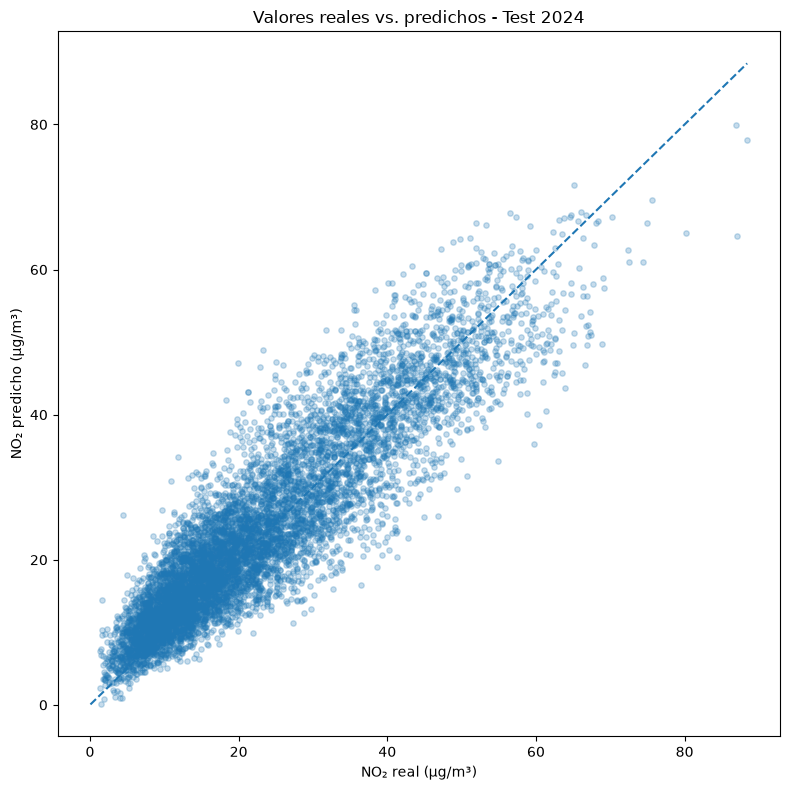

In [37]:
# ============================================================
# VALOR REAL VS PREDICCIÓN - TEST 2024
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    evaluacion_test[TARGET],
    evaluacion_test["prediccion"],
    alpha=0.25,
    s=15
)

lim_min = min(
    evaluacion_test[TARGET].min(),
    evaluacion_test["prediccion"].min()
)

lim_max = max(
    evaluacion_test[TARGET].max(),
    evaluacion_test["prediccion"].max()
)

plt.plot(
    [lim_min, lim_max],
    [lim_min, lim_max],
    linestyle="--"
)

plt.xlabel("NO₂ real (µg/m³)")
plt.ylabel("NO₂ predicho (µg/m³)")
plt.title("Valores reales vs. predichos - Test 2024")

plt.tight_layout()
plt.show()

### Análisis de valores reales frente a predichos

La representación de los valores reales frente a las predicciones del modelo muestra una clara concentración de las observaciones alrededor de la diagonal, que representa el escenario de predicción perfecta. Esto indica que el modelo reproduce adecuadamente la tendencia general de las concentraciones de NO₂ en el conjunto de test de 2024, en línea con el R² obtenido de **0.811**.

La mayor parte de las observaciones se concentra en niveles bajos y medios de NO₂, donde las predicciones presentan una buena correspondencia con los valores reales. A medida que aumenta la concentración se observa una mayor dispersión de las predicciones.

En particular, para algunos de los valores más elevados de NO₂ se aprecia una tendencia a situarse por debajo de la diagonal, indicando cierta **subestimación de los episodios de mayor concentración**. Este comportamiento coincide con el análisis realizado por rangos de NO₂, donde el mayor MAE se obtuvo para concentraciones superiores a 50 µg/m³.

En conjunto, la gráfica muestra una buena capacidad predictiva global, aunque también evidencia una menor precisión en los valores extremos, aspecto que deberá tenerse en cuenta como una de las limitaciones del modelo.

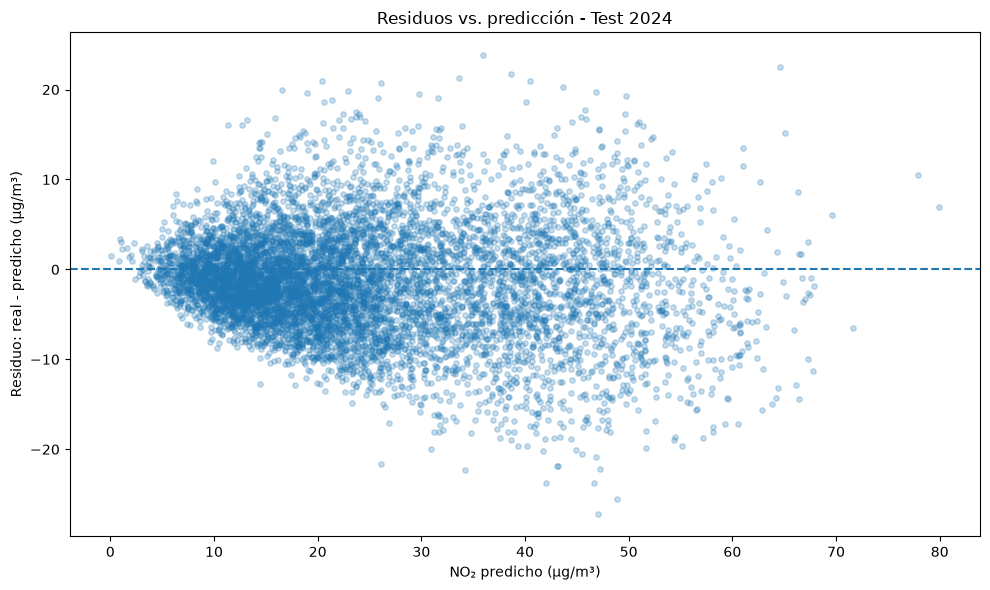

In [38]:
# ============================================================
# RESIDUOS VS PREDICCIÓN - TEST 2024
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    evaluacion_test["prediccion"],
    evaluacion_test["error"],
    alpha=0.25,
    s=15
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("NO₂ predicho (µg/m³)")
plt.ylabel("Residuo: real - predicho (µg/m³)")
plt.title("Residuos vs. predicción - Test 2024")

plt.tight_layout()
plt.show()

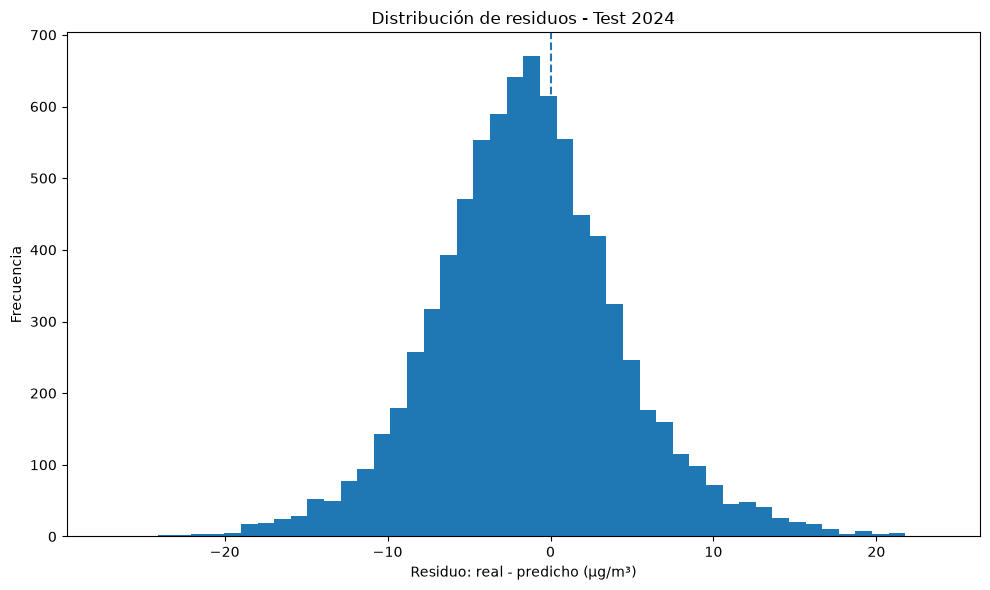

Residuo medio: -1.420930063940787
Mediana: -1.5064525604248038
Desviación típica: 5.815048079707022


In [39]:
# ============================================================
# DISTRIBUCIÓN DE RESIDUOS - TEST 2024
# ============================================================

plt.figure(figsize=(10, 6))

plt.hist(
    evaluacion_test["error"],
    bins=50
)

plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Residuo: real - predicho (µg/m³)")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos - Test 2024")

plt.tight_layout()
plt.show()

print("Residuo medio:", evaluacion_test["error"].mean())
print("Mediana:", evaluacion_test["error"].median())
print("Desviación típica:", evaluacion_test["error"].std())

### Análisis de residuos

El análisis de los residuos permite estudiar la diferencia entre los valores reales y las predicciones realizadas por el modelo, definiéndose el residuo como `valor real - valor predicho`.

En el gráfico de residuos frente a predicciones, los errores se distribuyen alrededor de cero sin observarse un patrón sistemático especialmente pronunciado. Sin embargo, se aprecia un aumento de la dispersión a medida que aumenta la concentración predicha de NO₂. Esto indica que el modelo presenta una mayor precisión para concentraciones bajas y medias, mientras que la incertidumbre de las predicciones aumenta en los niveles más elevados.

Este comportamiento es coherente con el análisis realizado por rangos de concentración, donde se observó un incremento del MAE para los valores más elevados de NO₂.

Por otro lado, la distribución de los residuos se encuentra concentrada alrededor de cero y presenta una forma aproximadamente acampanada, aunque existen errores extremos en ambas direcciones. Esto sugiere que el modelo no presenta visualmente un sesgo global muy pronunciado hacia la sobreestimación o la subestimación.

En conjunto, el análisis de residuos confirma el buen comportamiento general del modelo, aunque muestra una mayor dificultad para realizar predicciones precisas a medida que aumenta la concentración de NO₂.

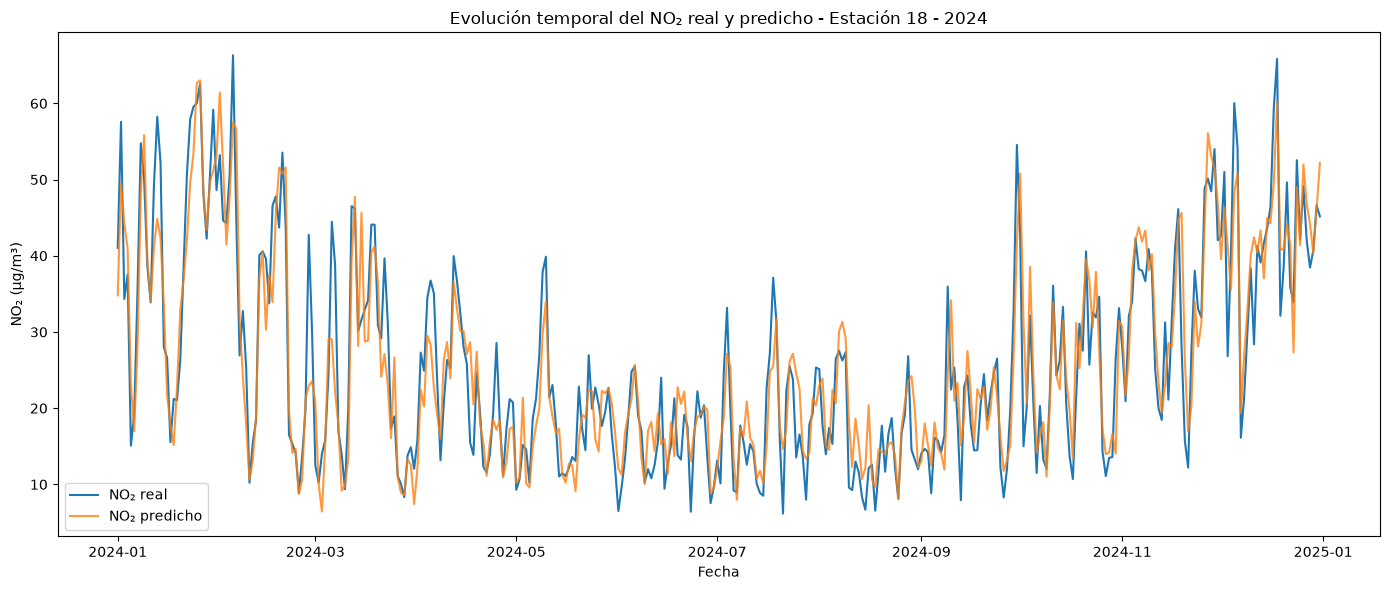

In [40]:
# ============================================================
# EVOLUCIÓN TEMPORAL REAL VS. PREDICHO - ESTACIÓN 18
# ============================================================

estacion_ejemplo = 18

serie_estacion = (
    evaluacion_test[
        evaluacion_test["estacion"] == estacion_ejemplo
    ]
    .sort_values("fecha")
)

plt.figure(figsize=(14, 6))

plt.plot(
    serie_estacion["fecha"],
    serie_estacion[TARGET],
    label="NO₂ real",
    linewidth=1.5
)

plt.plot(
    serie_estacion["fecha"],
    serie_estacion["prediccion"],
    label="NO₂ predicho",
    linewidth=1.5,
    alpha=0.8
)

plt.xlabel("Fecha")
plt.ylabel("NO₂ (µg/m³)")
plt.title(
    f"Evolución temporal del NO₂ real y predicho - "
    f"Estación {estacion_ejemplo} - 2024"
)

plt.legend()
plt.tight_layout()
plt.show()

### Evolución temporal de las predicciones

La evolución temporal de los valores reales y predichos permite comprobar la capacidad del modelo para reproducir la dinámica diaria del NO₂ a lo largo de 2024. Como ejemplo se representa la estación 18, cuyo comportamiento presenta un rendimiento representativo del buen ajuste obtenido por el modelo.

Las predicciones siguen de forma cercana la evolución de las concentraciones reales durante la mayor parte del año, reproduciendo tanto la variación estacional como una parte importante de las fluctuaciones diarias.

Se observa una mayor presencia de concentraciones elevadas durante los primeros y últimos meses del año, mientras que durante los meses centrales predominan valores inferiores. El modelo reproduce adecuadamente este patrón temporal.

Las principales diferencias aparecen ante algunos cambios especialmente bruscos y valores extremos, donde las predicciones tienden a presentar una menor amplitud que los valores observados. Este comportamiento es coherente con los análisis anteriores, que mostraron una mayor dificultad del modelo para predecir los episodios de concentraciones elevadas.

En conjunto, la comparación temporal muestra que el modelo no solo obtiene buenas métricas agregadas, sino que también es capaz de seguir adecuadamente la evolución diaria y estacional del NO₂.

In [41]:
# ============================================================
# SHAP - IMPORTACIÓN
# ============================================================

import shap

print("SHAP cargado correctamente.")
print("Versión:", shap.__version__)

SHAP cargado correctamente.
Versión: 0.52.0


In [42]:
# ============================================================
# CÁLCULO DE VALORES SHAP - MODELO FINAL
# ============================================================

explainer = shap.TreeExplainer(modelo_final)

shap_values = explainer(
    X_test_final
)

print("Valores SHAP calculados correctamente.")
print("Shape:", shap_values.values.shape)

Valores SHAP calculados correctamente.
Shape: (8052, 18)


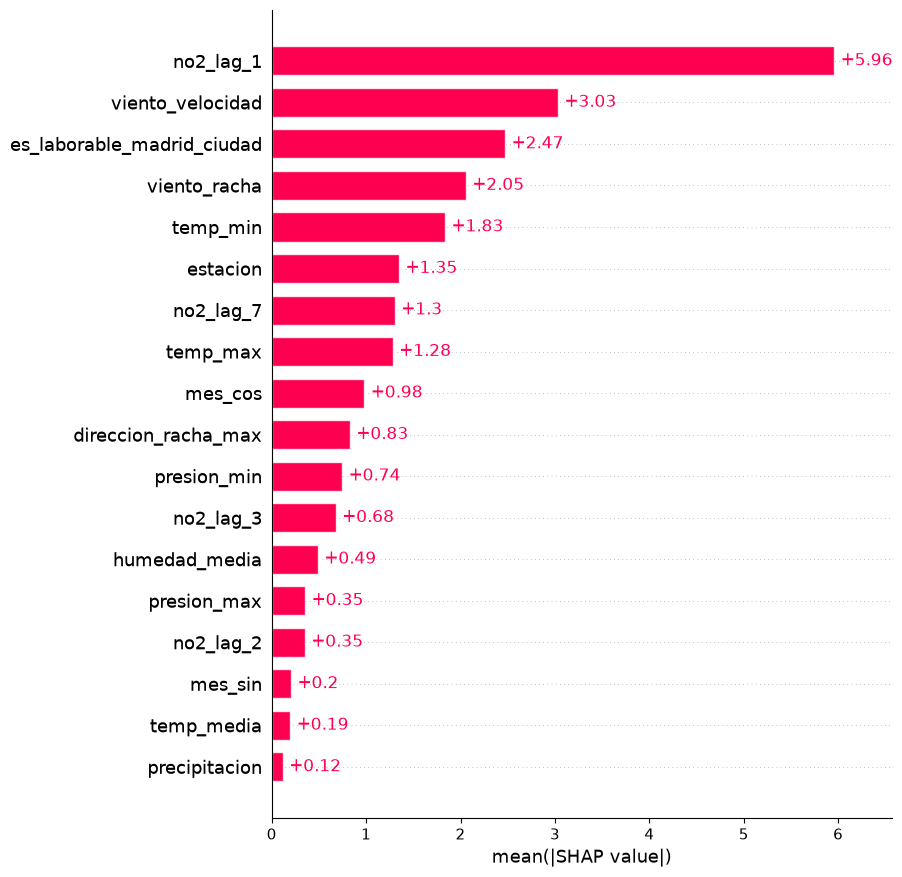

In [43]:
# ============================================================
# IMPORTANCIA GLOBAL DE VARIABLES - SHAP
# ============================================================

shap.plots.bar(
    shap_values,
    max_display=18
)

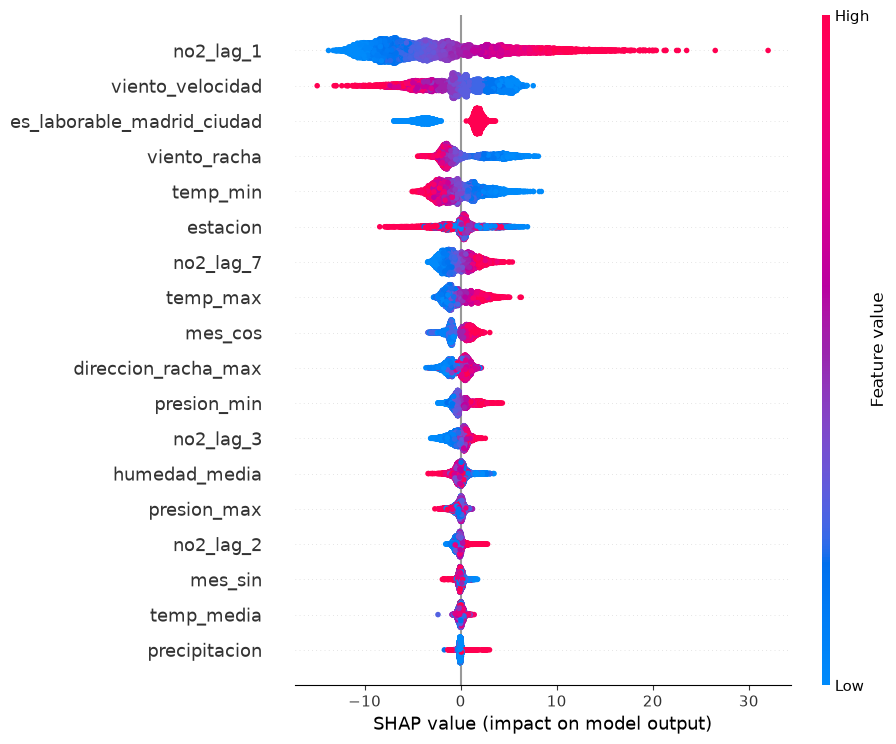

In [44]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.plots.beeswarm(
    shap_values,
    max_display=18
)

### Interpretación del modelo mediante SHAP

Para analizar la contribución de las variables a las predicciones del modelo final se utilizaron valores SHAP. Este método permite cuantificar tanto la importancia global de cada variable como la dirección de su influencia sobre las predicciones.

La variable con mayor impacto es `no2_lag_1`, correspondiente a la concentración de NO₂ del día anterior. Los valores elevados de esta variable presentan valores SHAP positivos, aumentando la predicción, mientras que los valores bajos contribuyen a reducirla. Esto refleja una fuerte persistencia temporal en las concentraciones de NO₂.

Entre las variables meteorológicas destaca especialmente `viento_velocidad`. Las velocidades elevadas del viento se asocian con contribuciones SHAP negativas, mientras que velocidades bajas presentan contribuciones positivas. El modelo identifica, por tanto, una asociación entre condiciones de mayor ventilación y menores concentraciones de NO₂, coherente con una mayor dispersión atmosférica. Un comportamiento similar se observa para `viento_racha`.

La variable `es_laborable_madrid_ciudad` también presenta una influencia relevante. Los días laborables tienden a contribuir positivamente a las predicciones, mientras que los días no laborables presentan principalmente contribuciones negativas. Este resultado muestra que el modelo identifica diferencias en las concentraciones de NO₂ asociadas al calendario de actividad de la ciudad.

Además del valor del día anterior, `no2_lag_7` presenta una contribución relevante, indicando que la concentración registrada una semana antes contiene información predictiva adicional. Los lags de dos y tres días muestran, en cambio, una influencia global considerablemente menor.

Las variables relacionadas con temperatura, estación, presión y humedad presentan también contribuciones al modelo, aunque de menor magnitud. En algunos casos sus efectos no muestran una relación estrictamente lineal, por lo que deben interpretarse teniendo en cuenta las posibles interacciones entre variables que puede capturar XGBoost.

En conjunto, el análisis SHAP muestra que las predicciones se apoyan principalmente en la persistencia temporal del NO₂, pero incorporan también información meteorológica, temporal y espacial relevante. Los resultados SHAP representan asociaciones aprendidas por el modelo y no deben interpretarse directamente como relaciones causales.

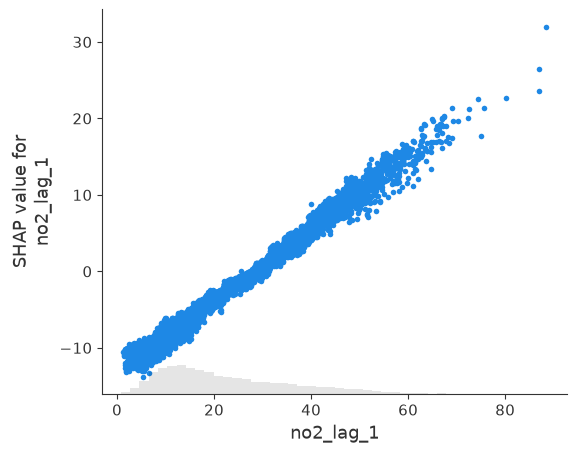

In [45]:
# ============================================================
# SHAP DEPENDENCE - NO2 LAG 1
# ============================================================

shap.plots.scatter(
    shap_values[:, "no2_lag_1"]
)

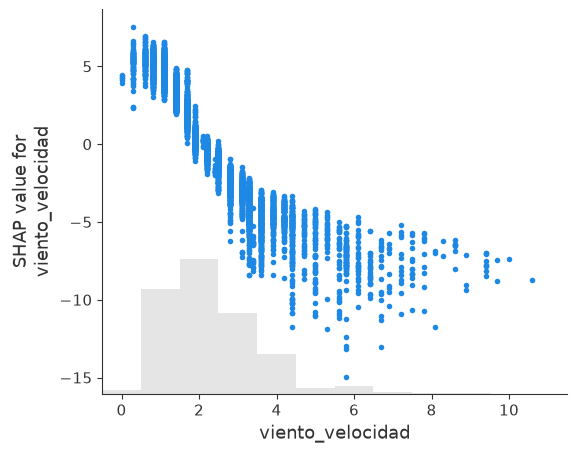

In [46]:
# ============================================================
# SHAP DEPENDENCE - VELOCIDAD DEL VIENTO
# ============================================================

shap.plots.scatter(
    shap_values[:, "viento_velocidad"]
    
)

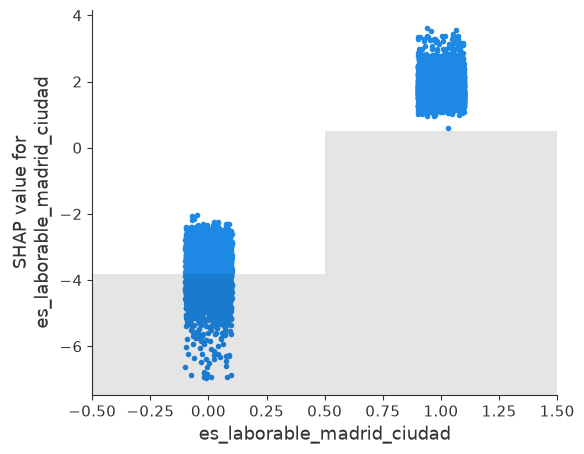

In [47]:
# ============================================================
# SHAP DEPENDENCE - DÍA LABORABLE
# ============================================================

shap.plots.scatter(
    shap_values[:, "es_laborable_madrid_ciudad"]
)

### Análisis de la influencia de las principales variables

Los gráficos de dependencia SHAP permiten analizar con mayor detalle cómo los valores de algunas de las variables más relevantes modifican las predicciones del modelo.

En el caso de `no2_lag_1` se observa una relación creciente muy clara. Concentraciones bajas de NO₂ en el día anterior presentan contribuciones SHAP negativas, mientras que concentraciones elevadas generan contribuciones progresivamente más positivas. Esto confirma la fuerte persistencia temporal del contaminante identificada previamente.

La variable `viento_velocidad` presenta una relación inversa y no lineal con la predicción. Las velocidades de viento más bajas muestran contribuciones positivas, mientras que el aumento de la velocidad produce una reducción progresiva de los valores SHAP. El efecto es especialmente pronunciado al pasar de condiciones de viento débil a velocidades moderadas y posteriormente tiende a estabilizarse. Este comportamiento es coherente con el papel del viento en la dispersión atmosférica de contaminantes.

Por último, `es_laborable_madrid_ciudad` muestra una separación clara entre sus dos posibles valores. Los días no laborables presentan contribuciones predominantemente negativas, mientras que los días laborables contribuyen positivamente a las predicciones de NO₂.

Este comportamiento puede estar relacionado con las diferencias en los patrones de movilidad y actividad urbana entre días laborables y no laborables. Durante los días laborables existe una mayor movilidad asociada, entre otros factores, a los desplazamientos por motivos de trabajo, lo que puede implicar una mayor intensidad de tráfico rodado. Dado que el tráfico constituye una fuente relevante de emisiones de NO₂ en entornos urbanos, este patrón proporciona una posible explicación de la relación identificada por el modelo.

No obstante, esta interpretación debe considerarse como una posible explicación del comportamiento observado y no como una relación causal demostrada, ya que el modelo no incorpora directamente información sobre la intensidad del tráfico.

En conjunto, estos resultados muestran que las principales relaciones aprendidas por el modelo presentan patrones interpretables y coherentes con la dinámica esperada de las concentraciones de NO₂. Los valores SHAP permiten explicar cómo utiliza el modelo cada variable para realizar sus predicciones, pero las asociaciones identificadas no implican necesariamente relaciones causales.

## Conclusiones del modelado

Se ha desarrollado un modelo XGBoost para la predicción diaria de las concentraciones de NO₂ en las estaciones de calidad del aire de Madrid.

El proceso de entrenamiento y selección se realizó mediante una división temporal de los datos, utilizando los años 2020-2022 para entrenamiento, 2023 para validación y selección del modelo, y 2024 como conjunto de test final.

Tras la optimización de hiperparámetros y el análisis de las variables disponibles, se seleccionó un modelo final compuesto por 18 variables. Posteriormente, el modelo definitivo fue reentrenado utilizando conjuntamente los datos de 2020-2023 y evaluado sobre el año 2024.

Los resultados finales obtenidos fueron:

- **MAE:** 4.620 µg/m³
- **RMSE:** 5.986 µg/m³
- **R²:** 0.811

Frente al modelo baseline basado en persistencia temporal, el modelo XGBoost consiguió reducir el MAE en un **32.02 %** y el RMSE en un **34.22 %**, mostrando una mejora sustancial de la capacidad predictiva.

El análisis detallado de los errores muestra un buen comportamiento general entre las distintas estaciones y niveles de concentración, aunque se observa una mayor incertidumbre en los episodios de NO₂ elevado y cierta tendencia a suavizar los valores extremos.

El análisis mediante SHAP muestra que la concentración de NO₂ del día anterior constituye la principal fuente de información del modelo. No obstante, las variables meteorológicas y de calendario también presentan una contribución relevante. Destacan especialmente la velocidad del viento y la condición de día laborable, cuyos efectos sobre las predicciones presentan patrones interpretables y coherentes.

En conjunto, los resultados muestran que el modelo es capaz de reproducir adecuadamente tanto la variabilidad temporal como las diferencias espaciales de las concentraciones de NO₂, proporcionando además un comportamiento interpretable mediante el análisis de sus variables predictoras.

In [48]:
# ============================================================
# GUARDAR MODELO FINAL
# ============================================================

import joblib

MODEL_PATH = ROOT / "models" / "xgboost_no2_final.joblib"

MODEL_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    modelo_final,
    MODEL_PATH
)

print("Modelo guardado correctamente:")
print(MODEL_PATH)

Modelo guardado correctamente:
c:\Users\borja\Desktop\Master\TFM\models\xgboost_no2_final.joblib


In [49]:
# ============================================================
# GUARDAR FEATURES DEL MODELO
# ============================================================

FEATURES_PATH = ROOT / "models" / "features_no2_final.joblib"

joblib.dump(
    FEATURES_FINAL,
    FEATURES_PATH
)

print("Features guardadas correctamente:")
print(FEATURES_PATH)

Features guardadas correctamente:
c:\Users\borja\Desktop\Master\TFM\models\features_no2_final.joblib


In [50]:
modelo_cargado = joblib.load(MODEL_PATH)
features_cargadas = joblib.load(FEATURES_PATH)

print("Modelo cargado correctamente.")
print("Número de features:", len(features_cargadas))
print(features_cargadas)

Modelo cargado correctamente.
Número de features: 18
['temp_media', 'temp_min', 'temp_max', 'humedad_media', 'precipitacion', 'direccion_racha_max', 'viento_velocidad', 'viento_racha', 'presion_max', 'presion_min', 'es_laborable_madrid_ciudad', 'mes_sin', 'mes_cos', 'estacion', 'no2_lag_1', 'no2_lag_2', 'no2_lag_3', 'no2_lag_7']
